# Vision Branch — MobileNetV3 Transfer-Learning Baseline

**In-Cabin Multi-Modal Driver Risk Assessment · FYP2 model training**

This notebook fine-tunes an ImageNet-pretrained **MobileNetV3** over the **10 State Farm-style
distraction classes** (c0 normal driving … c9 talking to passenger).

**Contract note.** The fusion layer consumes `P_distraction = 1 − P(c0 / safe driving)`. Trained
here as a 10-class problem; the distraction probability is derived downstream.

**Split.** Uses the **driver-grouped** train/val/test split prepared during EDA
(`vision_metadata_with_split.csv`) — no subject (driver) appears in more than one split, so the
reported accuracy is **not** inflated by per-driver background memorisation.

> ⚠️ **No horizontal-flip augmentation.** Classes encode left/right hand actions
> (texting-left vs texting-right, phone-left vs phone-right); a horizontal flip would silently
> corrupt the label. We use only rotation + colour jitter.

> ℹ️ **Why driver-grouped numbers look lower than typical Kaggle scores.** Random splits on this
> dataset leak driver/background cues and report ~0.99; the honest driver-grouped baseline is
> lower and is the correct number to report.

In [1]:
import os, json, time
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
import torch, torch.nn as nn, torchvision
from PIL import Image
from torch.utils.data import DataLoader, Dataset
from torchvision import models, transforms
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
print("torch", torch.__version__, "| torchvision", torchvision.__version__)

device = torch.device("mps") if torch.backends.mps.is_available() else (
         torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu"))
print("device:", device)
torch.manual_seed(42); np.random.seed(42)

torch 2.12.0 | torchvision 0.27.0
device: mps


## 1 · Hyperparameters

In [2]:
ARCH    = os.environ.get("VISION_ARCH", "large")   # "large" | "small"
EPOCHS  = int(os.environ.get("VISION_EPOCHS", "5"))
BATCH   = int(os.environ.get("VISION_BATCH", "64"))
LR      = float(os.environ.get("VISION_LR", "8e-4"))
# In a Jupyter kernel on macOS (Python 3.13), DataLoader(num_workers>0) is
# unreliable: spawn can't pickle the in-notebook Dataset class, and fork-after-
# threads (MPS already initialised) can crash the kernel. 0 = load in-process,
# always stable. Bump it ONLY if you run this as a plain script.
WORKERS = int(os.environ.get("VISION_WORKERS", "0"))
print(dict(arch=ARCH, epochs=EPOCHS, batch=BATCH, lr=LR, workers=WORKERS))

{'arch': 'large', 'epochs': 5, 'batch': 64, 'lr': 0.0008, 'workers': 0}


## 2 · Resolve paths & load the driver-grouped split

In [3]:
import os
from pathlib import Path

# --- Dataset location (override with env FYP_DATA_ROOT) ----------------------
# The EDA-prepared splits + images live in the *sibling* repo
# "FYP-In-Cabin-Driver-Assessment-" (note: no trailing 1). Nothing is copied;
# we read straight from there.
DATA_ROOT = Path(os.environ.get(
    "FYP_DATA_ROOT", str(Path.home() / "Desktop" / "FYP-In-Cabin-Driver-Assessment-")
)).expanduser()
assert DATA_ROOT.exists(), (
    f"Dataset root not found: {DATA_ROOT}\n"
    f"Set env FYP_DATA_ROOT to the repo that holds eda_outputs/."
)

# Outputs land under ml/outputs/ in THIS repo, regardless of where Jupyter was
# launched (kernel cwd may be the branch folder OR the repo root).
def _find_ml_outputs():
    here = Path.cwd().resolve()
    for p in [here, *here.parents]:
        if p.name == "ml":
            return p / "outputs"
        if (p / "ml" / "telemetry").exists():
            return p / "ml" / "outputs"
    return here / "outputs"

OUT = _find_ml_outputs()
print("DATA_ROOT:", DATA_ROOT)
print("OUTPUTS  :", OUT)

VIS_OUT = OUT / "vision"; VIS_OUT.mkdir(parents=True, exist_ok=True)
meta = pd.read_csv(DATA_ROOT / "eda_outputs" / "processed" / "vision" / "vision_metadata_with_split.csv")
CLASSES = sorted(meta["class_id"].unique())          # c0..c9
C2I = {c: i for i, c in enumerate(CLASSES)}
IDX2NAME = meta.drop_duplicates("class_id").set_index("class_id")["class_name"].to_dict()
NAMES = [f"{c}:{IDX2NAME[c]}" for c in CLASSES]
print("classes:", NAMES)
meta.groupby("split")["class_id"].count().rename("rows").to_frame()

DATA_ROOT: /Users/liu/Desktop/FYP-In-Cabin-Driver-Assessment-
OUTPUTS  : /Users/liu/Desktop/FYP-In-Cabin-Driver-Assessment--1/ml/outputs
classes: ['c0:normal_driving', 'c1:texting_right', 'c2:talking_phone_right', 'c3:texting_left', 'c4:talking_phone_left', 'c5:operating_radio', 'c6:drinking', 'c7:reaching_behind', 'c8:hair_makeup', 'c9:talking_to_passenger']


,rows
split,
test,3657
train,15899
val,2868


## 3 · Peek at a few frames (sanity check)

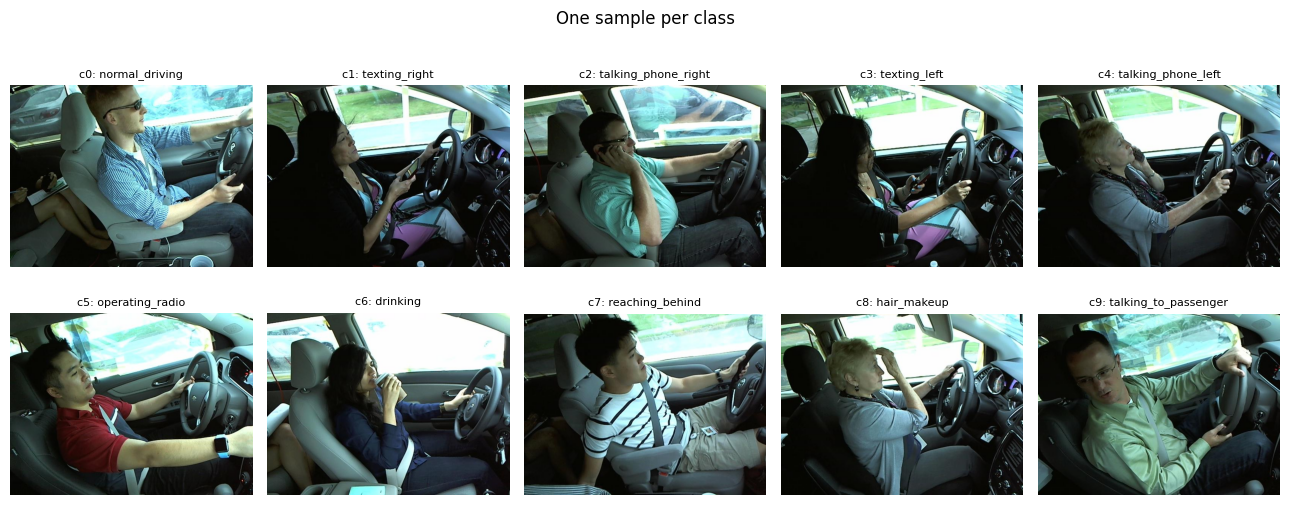

In [4]:
sample = meta.groupby("class_id").head(1).sort_values("class_id")
fig, axes = plt.subplots(2, 5, figsize=(13, 5.5))
for ax, (_, r) in zip(axes.ravel(), sample.iterrows()):
    ax.imshow(Image.open(r["image_path"])); ax.axis("off")
    ax.set_title(f'{r["class_id"]}: {r["class_name"]}', fontsize=8)
fig.suptitle("One sample per class"); fig.tight_layout(); plt.show()

## 4 · Datasets & transforms (no horizontal flip)

In [5]:
MEAN, STD = [0.485, 0.456, 0.406], [0.229, 0.224, 0.225]
train_tf = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomRotation(8),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(), transforms.Normalize(MEAN, STD)])
eval_tf = transforms.Compose([
    transforms.Resize((224, 224)), transforms.ToTensor(), transforms.Normalize(MEAN, STD)])

class FrameDataset(Dataset):
    def __init__(self, df, tf):
        self.paths = df["image_path"].tolist()
        self.labels = [C2I[c] for c in df["class_id"]]
        self.tf = tf
    def __len__(self): return len(self.paths)
    def __getitem__(self, i):
        return self.tf(Image.open(self.paths[i]).convert("RGB")), self.labels[i]

tr, va, te = (meta[meta.split == s] for s in ("train", "val", "test"))
def loader(df, tf, shuffle):
    return DataLoader(FrameDataset(df, tf), batch_size=BATCH, shuffle=shuffle,
                      num_workers=WORKERS, persistent_workers=False)
train_loader = loader(tr, train_tf, True)
val_loader   = loader(va, eval_tf, False)
print("batches  train/val:", len(train_loader), len(val_loader))

batches  train/val: 249 45


## 5 · Build MobileNetV3 (ImageNet-pretrained, new 10-class head)

In [6]:
def build_model(arch):
    if arch == "small":
        m = models.mobilenet_v3_small(weights=models.MobileNet_V3_Small_Weights.IMAGENET1K_V1)
    else:
        m = models.mobilenet_v3_large(weights=models.MobileNet_V3_Large_Weights.IMAGENET1K_V2)
    m.classifier[-1] = nn.Linear(m.classifier[-1].in_features, len(CLASSES))
    return m

model = build_model(ARCH).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)
sum(p.numel() for p in model.parameters())

4214842

## 6 · Train (keep best-val checkpoint)

In [7]:
@torch.no_grad()
def predict(loader_):
    model.eval(); ys, ps = [], []
    for x, y in loader_:
        ps.append(model(x.to(device)).argmax(1).cpu().numpy()); ys.append(np.asarray(y))
    return np.concatenate(ys), np.concatenate(ps)

history, best_val, best_state = [], -1.0, None
t_start = time.time()
for epoch in range(1, EPOCHS + 1):
    model.train(); running = seen = 0; t = time.time()
    for bi, (x, y) in enumerate(train_loader, 1):
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad(); loss = criterion(model(x), y); loss.backward(); optimizer.step()
        running += loss.item() * x.size(0); seen += x.size(0)
        if bi % 50 == 0:
            print(f"  e{epoch} batch {bi}/{len(train_loader)} loss={running/seen:.4f}", flush=True)
    scheduler.step()
    yv, pv = predict(val_loader)
    va_acc, va_f1 = accuracy_score(yv, pv), f1_score(yv, pv, average="macro")
    history.append({"epoch": epoch, "train_loss": running/seen, "val_acc": float(va_acc),
                    "val_macro_f1": float(va_f1), "seconds": round(time.time()-t, 1)})
    print(f"epoch {epoch}/{EPOCHS} train_loss={running/seen:.4f} "
          f"val_acc={va_acc:.4f} val_macroF1={va_f1:.4f} ({history[-1]['seconds']}s)", flush=True)
    if va_acc > best_val:
        best_val = va_acc
        best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
total_secs = round(time.time() - t_start, 1)
model.load_state_dict(best_state)
print(f"done in {total_secs}s; best_val_acc={best_val:.4f}")

  e1 batch 50/249 loss=0.7532


  e1 batch 100/249 loss=0.4488


  e1 batch 150/249 loss=0.3320


  e1 batch 200/249 loss=0.2684


epoch 1/5 train_loss=0.2298 val_acc=0.8013 val_macroF1=0.7676 (220.2s)


...

  e5 batch 100/249 loss=0.0013


  e5 batch 150/249 loss=0.0014


  e5 batch 200/249 loss=0.0014


epoch 5/5 train_loss=0.0013 val_acc=0.8975 val_macroF1=0.8907 (215.6s)


done in 1098.6s; best_val_acc=0.8975


## 7 · Evaluate on val + test (best-val checkpoint)

In [8]:
test_loader = loader(te, eval_tf, False)   # created lazily to save memory

def full_metrics(split, loader_):
    y, p = predict(loader_)
    rep = classification_report(y, p, labels=list(range(len(CLASSES))),
                                target_names=NAMES, output_dict=True, zero_division=0)
    m = {"accuracy": float(accuracy_score(y, p)),
         "macro_f1": float(f1_score(y, p, average="macro")),
         "weighted_f1": float(f1_score(y, p, average="weighted")),
         "per_class": {n: {"precision": rep[n]["precision"], "recall": rep[n]["recall"],
                           "f1": rep[n]["f1-score"], "support": rep[n]["support"]} for n in NAMES},
         "confusion_matrix": confusion_matrix(y, p, labels=list(range(len(CLASSES)))).tolist()}
    print(f"{split:>5}: acc={m['accuracy']:.4f}  macroF1={m['macro_f1']:.4f}")
    return m, y, p

val_m, _, _ = full_metrics("val", val_loader)
test_m, y_te, p_te = full_metrics("test", test_loader)
print("\n=== TEST classification report ===")
print(classification_report(y_te, p_te, labels=list(range(len(CLASSES))),
                            target_names=NAMES, digits=4, zero_division=0))

  val: acc=0.8975  macroF1=0.8907


 test: acc=0.8988  macroF1=0.8746

=== TEST classification report ===
                         precision    recall  f1-score   support

      c0:normal_driving     0.8102    0.9211    0.8621       431
       c1:texting_right     0.9813    0.9000    0.9389       350
 c2:talking_phone_right     0.9890    1.0000    0.9945       361
        c3:texting_left     0.9852    0.9803    0.9828       407
  c4:talking_phone_left     0.9483    0.9747    0.9613       395
     c5:operating_radio     0.9074    0.9901    0.9470       406
            c6:drinking     0.9102    0.9894    0.9482       379
     c7:reaching_behind     0.8503    0.9941    0.9166       337
         c8:hair_makeup     0.7664    0.8321    0.7979       280
c9:talking_to_passenger     0.7265    0.2733    0.3972       311

               accuracy                         0.8988      3657
              macro avg     0.8875    0.8855    0.8746      3657
           weighted avg     0.8930    0.8988    0.8856      3657



## 8 · Confusion matrix & training curve

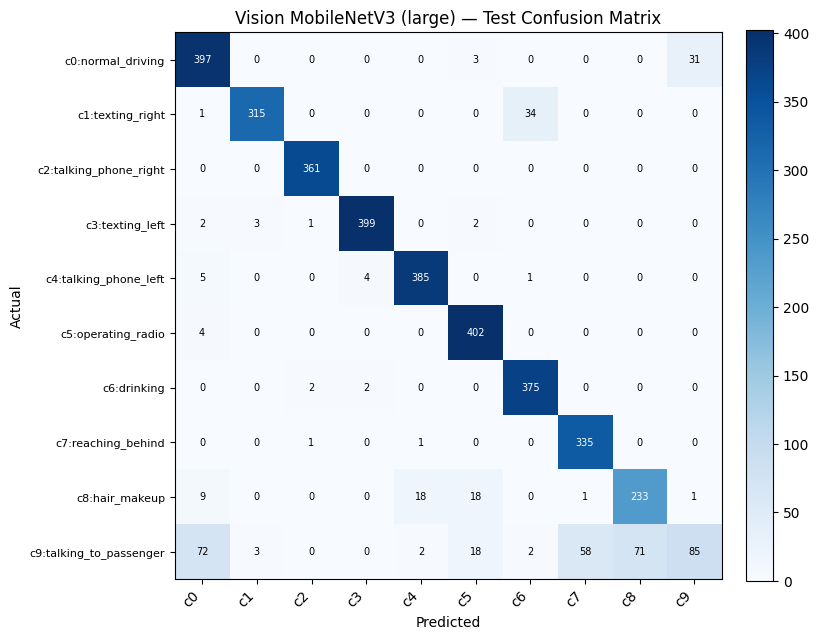

In [9]:
cm = np.array(test_m["confusion_matrix"])
fig, ax = plt.subplots(figsize=(8, 7))
im = ax.imshow(cm, cmap="Blues")
ax.set_xticks(range(len(NAMES)), [n.split(":")[0] for n in NAMES], rotation=45, ha="right")
ax.set_yticks(range(len(NAMES)), NAMES, fontsize=8)
ax.set_xlabel("Predicted"); ax.set_ylabel("Actual")
ax.set_title(f"Vision MobileNetV3 ({ARCH}) — Test Confusion Matrix")
th = cm.max()/2
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(j, i, int(cm[i, j]), ha="center", va="center", fontsize=7,
                color="white" if cm[i, j] > th else "black")
fig.colorbar(im, fraction=0.046, pad=0.04); fig.tight_layout()
fig.savefig(VIS_OUT / "confusion_matrix_test.png", dpi=150); plt.show()

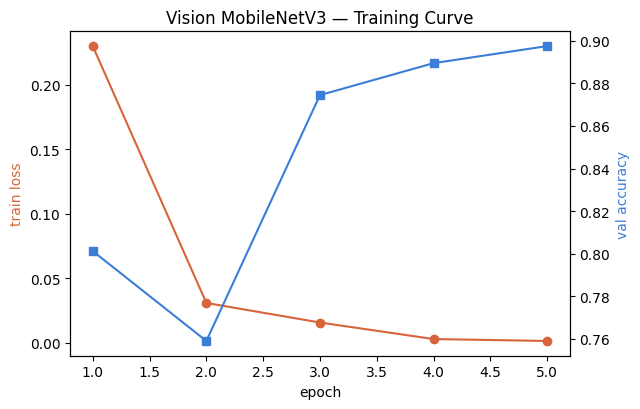

In [10]:
eps = [h["epoch"] for h in history]
fig, ax1 = plt.subplots(figsize=(6.5, 4.2))
ax1.plot(eps, [h["train_loss"] for h in history], "o-", color="#d8643b", label="train loss")
ax1.set_xlabel("epoch"); ax1.set_ylabel("train loss", color="#d8643b")
ax2 = ax1.twinx()
ax2.plot(eps, [h["val_acc"] for h in history], "s-", color="#3b7dd8", label="val acc")
ax2.set_ylabel("val accuracy", color="#3b7dd8")
ax1.set_title("Vision MobileNetV3 — Training Curve"); fig.tight_layout()
fig.savefig(VIS_OUT / "training_curve.png", dpi=150); plt.show()

## 9 · Persist model, metrics & ONNX export

In [11]:
torch.save({"state_dict": model.state_dict(), "classes": CLASSES,
            "idx_to_name": IDX2NAME, "arch": f"mobilenet_v3_{ARCH}"},
           VIS_OUT / f"mobilenetv3_{ARCH}_vision.pt")
summary = {
    "model": f"mobilenet_v3_{ARCH} (ImageNet-pretrained, fine-tuned)", "branch": "vision",
    "classes": CLASSES, "class_names": [IDX2NAME[c] for c in CLASSES], "num_classes": len(CLASSES),
    "split_sizes": {"train": int(len(tr)), "val": int(len(va)), "test": int(len(te))},
    "split_note": "driver-grouped (no subject leakage across splits)",
    "augmentation_note": "no horizontal flip (left/right hand is label-bearing)",
    "epochs": EPOCHS, "batch_size": BATCH, "lr": LR, "device": str(device),
    "train_seconds_total": total_secs, "best_val_acc": float(best_val), "history": history,
    "metrics": {"val": val_m, "test": test_m},
    "data_root": str(DATA_ROOT), "torch_version": torch.__version__,
}
(VIS_OUT / "metrics.json").write_text(json.dumps(summary, indent=2))
(VIS_OUT / "classification_report_test.txt").write_text(
    classification_report(y_te, p_te, labels=list(range(len(CLASSES))),
                          target_names=NAMES, digits=4, zero_division=0))

# ONNX export from CPU (tracing from an MPS-resident model is unreliable).
# dynamo=False uses the legacy exporter: depends only on `onnx` (not onnxscript),
# and is reliable for this CNN. Aligns with the demo plan (MobileNetV3 ONNX).
model.eval().to("cpu")
torch.onnx.export(model, torch.randn(1, 3, 224, 224),
                  str(VIS_OUT / f"mobilenetv3_{ARCH}_vision.onnx"),
                  input_names=["input"], output_names=["logits"], opset_version=17,
                  dynamic_axes={"input": {0: "batch"}, "logits": {0: "batch"}}, dynamo=False)
print("saved ->", VIS_OUT)
print(f"TEST baseline: acc={test_m['accuracy']:.4f}  macroF1={test_m['macro_f1']:.4f}  "
      f"(best_val_acc={best_val:.4f})")

/tmp/claude-501/ipykernel_30055/3580106594.py:24: DeprecationWarning: You are using the legacy TorchScript-based ONNX export. Starting in PyTorch 2.9, the new torch.export-based ONNX exporter has become the default. Learn more about the new export logic: https://docs.pytorch.org/docs/stable/onnx_export.html. For exporting control flow: https://pytorch.org/tutorials/beginner/onnx/export_control_flow_model_to_onnx_tutorial.html
  torch.onnx.export(model, torch.randn(1, 3, 224, 224),


saved -> /Users/liu/Desktop/FYP-In-Cabin-Driver-Assessment--1/ml/outputs/vision
TEST baseline: acc=0.8988  macroF1=0.8746  (best_val_acc=0.8975)


## 10 · Final summary (report-ready)

In [12]:
# Reads the metrics it just wrote, so this cell is a stable, copy-paste-ready
# block for the report (re-runnable on its own once metrics.json exists).
import json, pandas as pd
S = json.loads((VIS_OUT / "metrics.json").read_text())
t, v = S["metrics"]["test"], S["metrics"]["val"]
print("=" * 64)
print(f"VISION BRANCH — {S['model']}")
print("=" * 64)
print(f"Split   : train/val/test = {S['split_sizes']['train']}/"
      f"{S['split_sizes']['val']}/{S['split_sizes']['test']}  ({S['split_note']})")
print(f"Val     : accuracy={v['accuracy']:.4f}  macro-F1={v['macro_f1']:.4f}")
print(f"Test    : accuracy={t['accuracy']:.4f}  macro-F1={t['macro_f1']:.4f}  "
      f"weighted-F1={t['weighted_f1']:.4f}")
print(f"Setup   : best_val_acc={S['best_val_acc']:.4f}  epochs={S['epochs']}  "
      f"batch={S['batch_size']}  lr={S['lr']}  device={S['device']}  ({S['train_seconds_total']}s)")
print()
pc = pd.DataFrame(t["per_class"]).T[["precision", "recall", "f1", "support"]].round(4)
print("Per-class (test):"); print(pc.to_string())
print()
print("Notes   :", S["augmentation_note"])
print(f"Artifacts: {VIS_OUT}")

VISION BRANCH — mobilenet_v3_large (ImageNet-pretrained, fine-tuned)
Split   : train/val/test = 15899/2868/3657  (driver-grouped (no subject leakage across splits))
Val     : accuracy=0.8975  macro-F1=0.8907
Test    : accuracy=0.8988  macro-F1=0.8746  weighted-F1=0.8856
Setup   : best_val_acc=0.8975  epochs=5  batch=64  lr=0.0008  device=mps  (1098.6s)

Per-class (test):
                         precision  recall      f1  support
c0:normal_driving           0.8102  0.9211  0.8621    431.0
c1:texting_right            0.9813  0.9000  0.9389    350.0
c2:talking_phone_right      0.9890  1.0000  0.9945    361.0
c3:texting_left             0.9852  0.9803  0.9828    407.0
c4:talking_phone_left       0.9483  0.9747  0.9613    395.0
c5:operating_radio          0.9074  0.9901  0.9470    406.0
c6:drinking                 0.9102  0.9894  0.9482    379.0
c7:reaching_behind          0.8503  0.9941  0.9166    337.0
c8:hair_makeup              0.7664  0.8321  0.7979    280.0
c9:talking_to_passenger   

---
### Interpretation notes (for report / viva)

- **`P_distraction = 1 − P(c0)`** is what the fusion layer ingests; this notebook trains the full
  10-class classifier and the distraction probability is derived downstream.
- The reported accuracy is from a **driver-grouped** split — the honest generalisation estimate.
  A random split would report a higher but **leaky** number; do not quote that.
- Augmentation deliberately **excludes horizontal flips** because left/right hand actions are
  distinct labels.
- This is a **transfer-learning baseline** (pretrained backbone, fine-tuned). Stronger results are
  possible with longer schedules, class-balanced sampling, or test-time augmentation — listed as
  future work, not claimed here.